In [5]:
import numpy as np
from astropy import units as u
from astropy.table import Table
from astropy.time import Time
from WDBinary import WDBinary

from scipy import integrate
from astropy.constants import G, c, M_sun

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

WD masses in binary systems range from 0.8 - 1.14 solar masses, and avg radius is 0.01 solar radii
NS avg mass 1.4 solar masses, avg radius is 15km
BH masses (stellar-mass) 5-150 solar masses, (radius around 30 km for 10 solar masses)


In [6]:
N = 5000
m_wd = 0.63
m_s = 1.1
r_wd = 0.0133 * u.R_sun 
r_s = 1.0 * u.R_sun
a = 10 * u.R_sun
e = 0 #0.061
period = 683.267 
L_star = 1.0
L_wd = 0.001
t = np.linspace(0, (period*u.day).to(u.yr).value, N) * u.yr
d = 50 * u.pc
inc = 90 *u.deg

prob something with E calculation

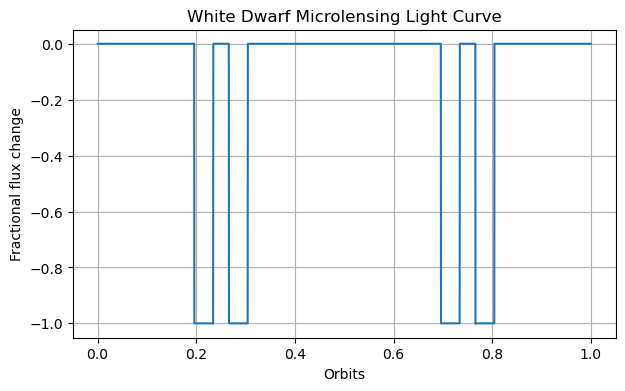

In [7]:
test1 = WDBinary(m_wd, r_wd, L_wd, m_s, r_s, L_star, e, a, d, t, inc=inc, period=period)
test1.plot_light_curve(t)

## MC Calcualtion ##

In [94]:
def einstein_radius_circ(M, a, D):
    r_E = np.sqrt((2 * G * M * a) / (c**2 * D * (D + a)))
    return (r_E * D).to(u.Rsun)
    
def transit_prob(r_E, r_star, a):
    return (r_E + r_star) / a

In [95]:
def sample_rstar_from_mstar(Mstar, N, sigma_logR=0.1):
    if Mstar.value < 1.0:
        alpha = 0.8
    elif Mstar.value < 10.0:
        alpha = 0.57
    else:
        alpha = 0.3

    Rmean = Mstar.value**alpha
    logR = np.log10(Rmean) + np.random.normal(0, sigma_logR, N)
    return 10**logR * u.Rsun

def sample_cosi(N):
    return np.random.uniform(0, 1, N)

def transit_condition(a, cosi, Rstar, rE):
    r = a * cosi

    if Rstar.size > 1:
        rE_arr = rE

        if rE.size == 1:
            rE_arr = np.ones(Rstar.size) * rE
        
        cond = Rstar + rE_arr

    return r < cond

In [96]:
def transit_prob_Mlens(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    Rstar = sample_rstar_from_mstar(Mstar, N, sigma_logR)
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [97]:
def transit_prob_a(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    Rstar = sample_rstar_from_mstar(Mstar, N, sigma_logR)
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [98]:
def transit_prob_Rstar(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [102]:
a_vals = np.logspace(-2, 1, 50) * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=0.6*u.Msun, D=26.8*u.pc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)


[0.4807  0.41572 0.36072 0.31442 0.27445 0.23692 0.20525 0.18052 0.15607
 0.13432 0.11761 0.10338 0.08871 0.07734 0.06661 0.05783 0.05103 0.04383
 0.03812 0.03394 0.02891 0.02495 0.02177 0.01848 0.01643 0.01492 0.0127
 0.01072 0.00917 0.00772 0.00717 0.00597 0.00584 0.00468 0.004   0.00383
 0.00325 0.00271 0.00219 0.00175 0.00176 0.00139 0.00133 0.00103 0.00109
 0.00076 0.00092 0.00073 0.00071 0.00051]
[48070 41572 36072 31442 27445 23692 20525 18052 15607 13432 11761 10338
  8871  7734  6661  5783  5103  4383  3812  3394  2891  2495  2177  1848
  1643  1492  1270  1072   917   772   717   597   584   468   400   383
   325   271   219   175   176   139   133   103   109    76    92    73
    71    51]
[ 0.01        0.01151395  0.01325711  0.01526418  0.01757511  0.0202359
  0.02329952  0.02682696  0.03088844  0.0355648   0.04094915  0.04714866
  0.05428675  0.06250552  0.07196857  0.08286428  0.09540955  0.10985411
  0.12648552  0.14563485  0.16768329  0.19306977  0.22229965  0.255954

Text(0.5, 0, 'a (AU)')

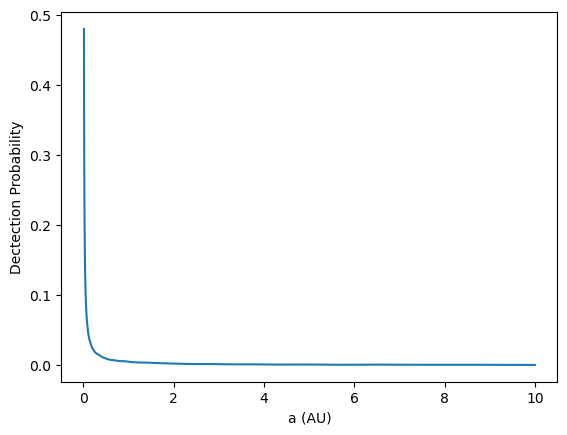

In [104]:
plt.plot(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")

In [122]:
Mlens_vals = np.linspace(0.1, 10, 1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.pc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)

[0.00463 0.00459 0.00486 0.00475 0.00485 0.00451 0.0045  0.00488 0.00492
 0.00501 0.00486 0.00493 0.00502 0.0052  0.00491 0.0047  0.00484 0.00487
 0.005   0.00477 0.00477 0.00505 0.0049  0.00485 0.0045  0.00471 0.00477
 0.00464 0.00521 0.00508 0.00521 0.00495 0.00505 0.00477 0.00486 0.00485
 0.00463 0.00471 0.00456 0.00507 0.00488 0.00498 0.00479 0.00493 0.00477
 0.00505 0.00474 0.00486 0.00488 0.00515 0.00457 0.0047  0.00526 0.005
 0.00478 0.00468 0.00484 0.00524 0.0048  0.00483 0.00471 0.00462 0.00468
 0.00515 0.00417 0.00516 0.00493 0.00498 0.00492 0.00448 0.0051  0.00492
 0.00474 0.0055  0.00512 0.00508 0.00432 0.00512 0.00469 0.00483 0.00489
 0.005   0.00495 0.00489 0.00494 0.00485 0.00461 0.00508 0.00531 0.00496
 0.00473 0.00561 0.00492 0.00483 0.00447 0.00477 0.00506 0.00479 0.00512
 0.00509 0.00474 0.00512 0.00475 0.00491 0.00452 0.00518 0.00498 0.00483
 0.00514 0.00503 0.00498 0.00483 0.00492 0.00483 0.00477 0.0049  0.0049
 0.00533 0.00479 0.00507 0.00491 0.00498 0.00478 0.005

Text(0.5, 0, '$M_\\mathrm{lens} (M_\\odot)$')

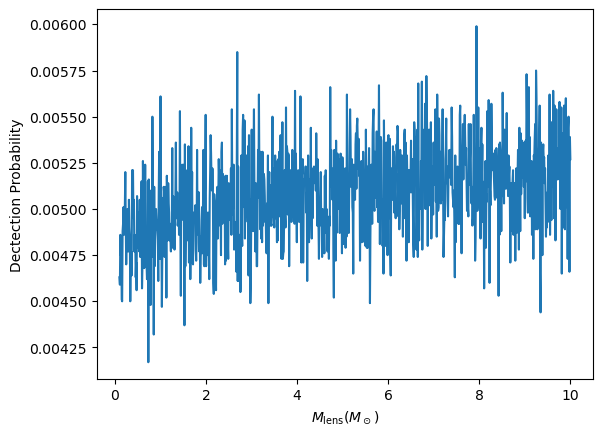

In [123]:
plt.plot(Mlens_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{lens} (M_\odot)$")

In [124]:
Mstar_vals = np.linspace(0.2, 5, 1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=M, Mlens=0.6*u.Msun, D=26.8*u.pc)
           for M in Mstar_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mstar_vals)


[0.0015  0.00145 0.00136 0.00159 0.00133 0.00159 0.00181 0.00182 0.00145
 0.00164 0.0018  0.0019  0.00184 0.00158 0.00193 0.00193 0.00186 0.00179
 0.00203 0.00196 0.00203 0.00183 0.00188 0.00201 0.00208 0.00207 0.00192
 0.00203 0.00226 0.0022  0.002   0.00243 0.00195 0.00226 0.00225 0.00233
 0.0025  0.00247 0.00228 0.00224 0.00231 0.00232 0.00247 0.00224 0.00223
 0.00237 0.00265 0.00231 0.00234 0.00268 0.00267 0.00249 0.00267 0.00271
 0.00261 0.00286 0.00255 0.00277 0.00278 0.00272 0.0028  0.00267 0.00285
 0.00301 0.00273 0.00298 0.00327 0.00294 0.00285 0.00295 0.00303 0.00325
 0.00329 0.00314 0.0031  0.00296 0.00302 0.00312 0.00334 0.00357 0.00314
 0.0031  0.00342 0.00347 0.00336 0.00346 0.00333 0.0035  0.00321 0.00329
 0.00352 0.00321 0.00319 0.00358 0.00324 0.00337 0.00338 0.00353 0.00379
 0.00384 0.00315 0.00351 0.00366 0.00374 0.00349 0.00374 0.00358 0.00357
 0.00369 0.00374 0.00343 0.00359 0.00399 0.00371 0.00373 0.00402 0.00372
 0.0036  0.00412 0.00439 0.00415 0.00385 0.00395 0.

Text(0.5, 0, '$M_\\mathrm{*} (M_\\odot)$')

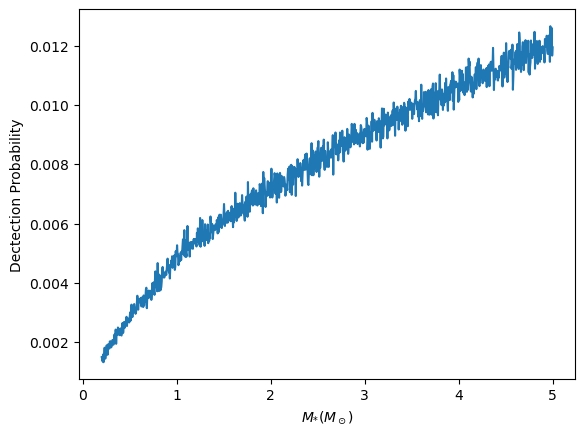

In [125]:
plt.plot(Mstar_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{*} (M_\odot)$")

## BH SLB DETECABILITY RECALCULATION ##

In [ ]:
def sample_bh_masses(N, m_min=5.0, m_max=50.0, alpha=2.3):
    inv = 1.0 - alpha
    c0 = m_min**inv
    c1 = m_max**inv
    r = np.random.rand(N)
    masses = (c0 + (c1 - c0)*r)**(1.0/inv)
    return masses

# replace your linspace with this:
Mlens_vals = sample_bh_masses(100) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.pc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)